In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from PIL import Image

In [39]:
train_dir = "/content/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "/content/DevanagariHandwrittenDigitDataset/Test/"

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

Train exists: True
Test exists: True


 Define image size and data loading function

In [42]:
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_names = [name for name in class_names if os.path.isdir(os.path.join(folder, name))]
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img, dtype=np.float32) / 255.0
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping file {img_path} error: {e}")

    return np.array(images), np.array(labels)

Load training and testing data

In [43]:
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (17000, 28, 28)
Training labels shape: (17000,)
Testing images shape: (3000, 28, 28)
Testing labels shape: (3000,)


Reshape images for Keras

In [44]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Reshaped x_train:", x_train.shape)
print("Reshaped x_test:", x_test.shape)

Reshaped x_train: (17000, 28, 28, 1)
Reshaped x_test: (3000, 28, 28, 1)


One-hot encode labels

In [45]:
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print("Encoded y_train shape:", y_train.shape)
print("Encoded y_test shape:", y_test.shape)

Encoded y_train shape: (17000, 10)
Encoded y_test shape: (3000, 10)


Visualize sample images

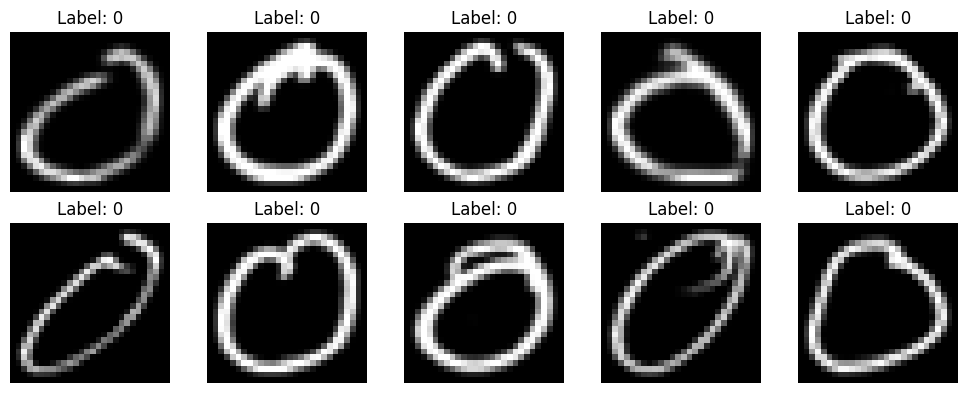

In [46]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Build the FCN model

In [48]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(64, activation="sigmoid"),
    layers.Dense(128, activation="sigmoid"),
    layers.Dense(256, activation="sigmoid"),
    layers.Dense(10, activation="softmax")
])

Show model summary

In [49]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Compile the model

In [50]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Train the model

In [51]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4903 - loss: 1.5904 - val_accuracy: 0.0000e+00 - val_loss: 7.7014
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8292 - loss: 0.5198 - val_accuracy: 0.0000e+00 - val_loss: 9.0267
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9083 - loss: 0.3001 - val_accuracy: 0.0000e+00 - val_loss: 9.7326
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9404 - loss: 0.2059 - val_accuracy: 0.0000e+00 - val_loss: 10.3956
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9567 - loss: 0.1534 - val_accuracy: 0.0000e+00 - val_loss: 10.5365
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9660 - loss: 0.1208 - val_accuracy: 0.0000e+00 - val_loss: 10.8451
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9712 - loss: 0.1009 - val_accuracy: 0.0000e+00 - val_loss: 10.9629
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9783

Plot training and validation loss/accuracy

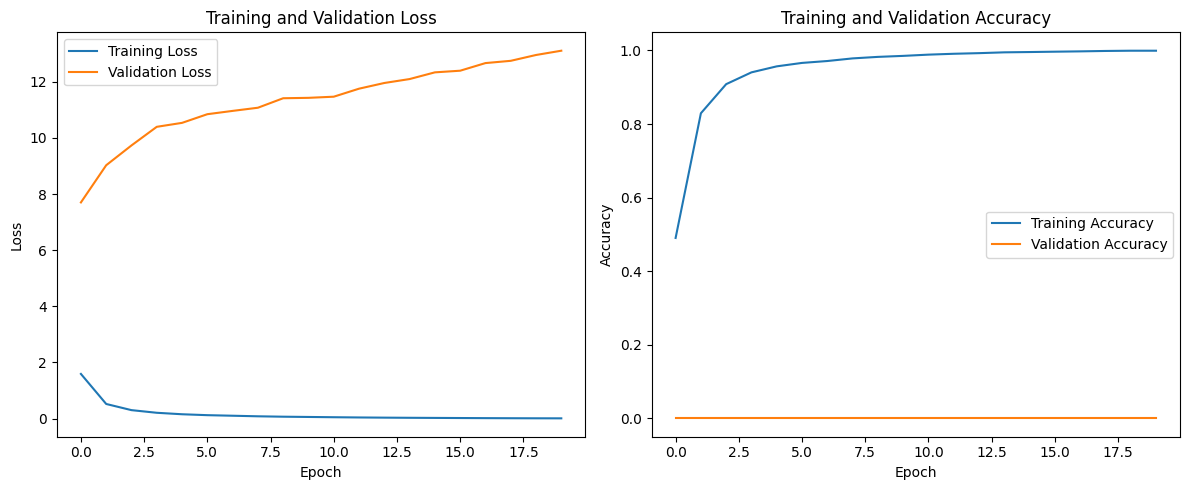

In [52]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Evaluate the model on test set

In [53]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.7827 - loss: 2.6813
Test Loss: 2.6813
Test Accuracy: 0.7827


Make predictions

In [54]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted label for first image:", predicted_labels[0])
print("True label for first image:", true_labels[0])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted label for first image: 0
True label for first image: 0


Show some prediction results visually

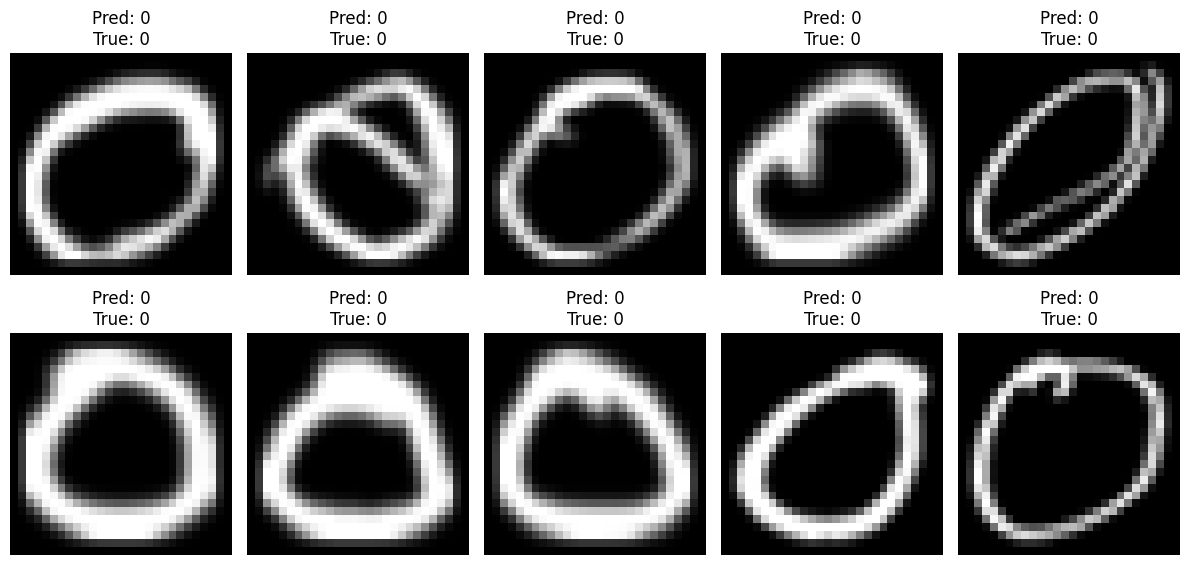

In [55]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Save the model

In [56]:
model.save("devnagari_fcn_model.h5")
print("Model saved successfully!")

Model saved successfully!


Load the saved model

In [57]:
loaded_model = tf.keras.models.load_model("devnagari_fcn_model.h5")
print("Model loaded successfully!")

Model loaded successfully!


Re-evaluate loaded model

In [58]:
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"Loaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

94/94 - 1s - 15ms/step - accuracy: 0.7827 - loss: 2.6813
Loaded Model Test Loss: 2.6813
Loaded Model Test Accuracy: 0.7827


Final conclusion cell

In [59]:
conclusion = """
This worksheet implemented a Fully Connected Network (FCN) for Devnagari handwritten digit classification using TensorFlow and Keras.
The images were loaded manually using PIL, converted to grayscale, resized to 28x28, normalized, and reshaped for Keras compatibility.
The FCN model was built using three hidden dense layers with 64, 128, and 256 neurons, all using sigmoid activation, followed by a 10-class softmax output layer.
The model was compiled with the Adam optimizer and categorical crossentropy loss, trained for 20 epochs with batch size 128, and evaluated on the test set.
The training and validation graphs helped analyze the learning performance, and the trained model was successfully saved and loaded again for reuse.
"""
print(conclusion)


This worksheet implemented a Fully Connected Network (FCN) for Devnagari handwritten digit classification using TensorFlow and Keras.
The images were loaded manually using PIL, converted to grayscale, resized to 28x28, normalized, and reshaped for Keras compatibility.
The FCN model was built using three hidden dense layers with 64, 128, and 256 neurons, all using sigmoid activation, followed by a 10-class softmax output layer.
The model was compiled with the Adam optimizer and categorical crossentropy loss, trained for 20 epochs with batch size 128, and evaluated on the test set.
The training and validation graphs helped analyze the learning performance, and the trained model was successfully saved and loaded again for reuse.

